# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Elviyanti
- **Email:** elviyanti.tik23@stu.pnj.ac.id
- **ID Dicoding:** Elviyanti

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Negara bagian (*state*) mana yang memiliki jumlah pelanggan terbanyak, dan bagaimana persebarannya di seluruh Brasil?
- **Pertanyaan 2:** Bagaimana distribusi pelanggan berdasarkan wilayah (*region*) Brasil, dan wilayah mana yang paling sedikit terpenetrasi oleh e-commerce?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [4]:
from google.colab import files
uploaded = files.upload()

Saving customers_dataset.csv to customers_dataset.csv


In [6]:
# Load dataset
df = pd.read_csv('customers_dataset.csv')

df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- Dataset memuat **99.441 baris** dan **5 kolom**.
- Kolom yang tersedia: `customer_id`, `customer_unique_id`, `customer_zip_code_prefix`, `customer_city`, dan `customer_state`.
- Terdapat perbedaan antara `customer_id` (ID transaksi) dan `customer_unique_id` (ID pelanggan unik), artinya satu pelanggan bisa memiliki lebih dari satu transaksi.

### Assessing Data

In [9]:
#Cek missing values
missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)' : (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing)
print()

#Cek duplikat
print(f'Baris duplikat     : {df.duplicated().sum()}')
print(f'customer_id unik   : {df["customer_id"].nunique():,}')
print(f'customer_unique_id : {df["customer_unique_id"].nunique():,}')
print()

#Cek distribusi state top 10
print(df['customer_state'].value_counts().head(10))

                          Jumlah Missing  Persentase (%)
customer_id                            0             0.0
customer_unique_id                     0             0.0
customer_zip_code_prefix               0             0.0
customer_city                          0             0.0
customer_state                         0             0.0

Baris duplikat     : 0
customer_id unik   : 99,441
customer_unique_id : 96,096

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


**Insight:**
- **Tidak ada missing values**
- **Tidak ada baris duplikat** pada dataset.
- Selisih antara `customer_id` (99.441) dan `customer_unique_id` (96.096) menunjukkan ada **3.345 pelanggan** yang melakukan lebih dari satu transaksi.
- Negara bagian **SP** mendominasi dengan 41.746 pelanggan, jauh melampaui negara bagian lainnya.

### Cleaning Data

In [12]:
# Standardisasi format teks
df['customer_city']  = df['customer_city'].str.strip().str.lower()
df['customer_state'] = df['customer_state'].str.strip().str.upper()

# Tambah kolom region (wilayah Brasil)
region_map = {
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    'RS': 'Sul',     'PR': 'Sul',     'SC': 'Sul',
    'BA': 'Nordeste','CE': 'Nordeste','PE': 'Nordeste','MA': 'Nordeste',
    'PB': 'Nordeste','RN': 'Nordeste','AL': 'Nordeste','SE': 'Nordeste','PI': 'Nordeste',
    'PA': 'Norte',   'AM': 'Norte',   'RO': 'Norte',   'AC': 'Norte',
    'AP': 'Norte',   'RR': 'Norte',   'TO': 'Norte',
    'GO': 'Centro-Oeste','MT': 'Centro-Oeste','MS': 'Centro-Oeste','DF': 'Centro-Oeste'
}
df['region'] = df['customer_state'].map(region_map)

print(f'Shape akhir: {df.shape}')
print()
print('Contoh data setelah cleaning:')
df.head()

Shape akhir: (99441, 6)

Contoh data setelah cleaning:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,region
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,Sudeste
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,Sudeste
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,Sudeste
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,Sudeste
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,Sudeste


**Insight:**
- Dilakukan **standardisasi teks** pada `customer_city` (strip + lowercase) dan `customer_state` (strip + uppercase) untuk konsistensi.
- Ditambahkan kolom baru **`region`** yang memetakan 27 negara bagian Brasil ke 5 wilayah utama (Sudeste, Sul, Nordeste, Norte, Centro-Oeste).
- Data sudah bersih dan siap untuk dianalisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore Distribusi Pelanggan per State dan Region

In [13]:
# Distribusi per State
state_dist = (df['customer_state']
              .value_counts()
              .reset_index()
              .rename(columns={'customer_state':'state','count':'jumlah'}))
state_dist['persen'] = (state_dist['jumlah'] / state_dist['jumlah'].sum() * 100).round(2)

print('state')
print(state_dist.head(10).to_string(index=False))

print()

#Distribusi per Region
region_dist = (df['region']
               .value_counts()
               .reset_index()
               .rename(columns={'region':'wilayah','count':'jumlah'}))
region_dist['persen'] = (region_dist['jumlah'] / region_dist['jumlah'].sum() * 100).round(2)

print('region')
print(region_dist.to_string(index=False))

state
state  jumlah  persen
   SP   41746   41.98
   RJ   12852   12.92
   MG   11635   11.70
   RS    5466    5.50
   PR    5045    5.07
   SC    3637    3.66
   BA    3380    3.40
   DF    2140    2.15
   ES    2033    2.04
   GO    2020    2.03

region
     wilayah  jumlah  persen
     Sudeste   68266   68.65
         Sul   14148   14.23
    Nordeste    9394    9.45
Centro-Oeste    5782    5.81
       Norte    1851    1.86


**Insight:**
- **SP, RJ, MG, RS, PR** adalah lima negara bagian teratas, menyumbang **~73%** dari total pelanggan.
- Wilayah **Sudeste** mendominasi dengan **68.65%** pelanggan, sementara wilayah **Norte** hanya **1.86%**.
- Ketidakseimbangan ini mengindikasikan peluang ekspansi pasar yang besar di wilayah timur dan utara Brasil.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Negara bagian mana yang memiliki jumlah pelanggan terbanyak?

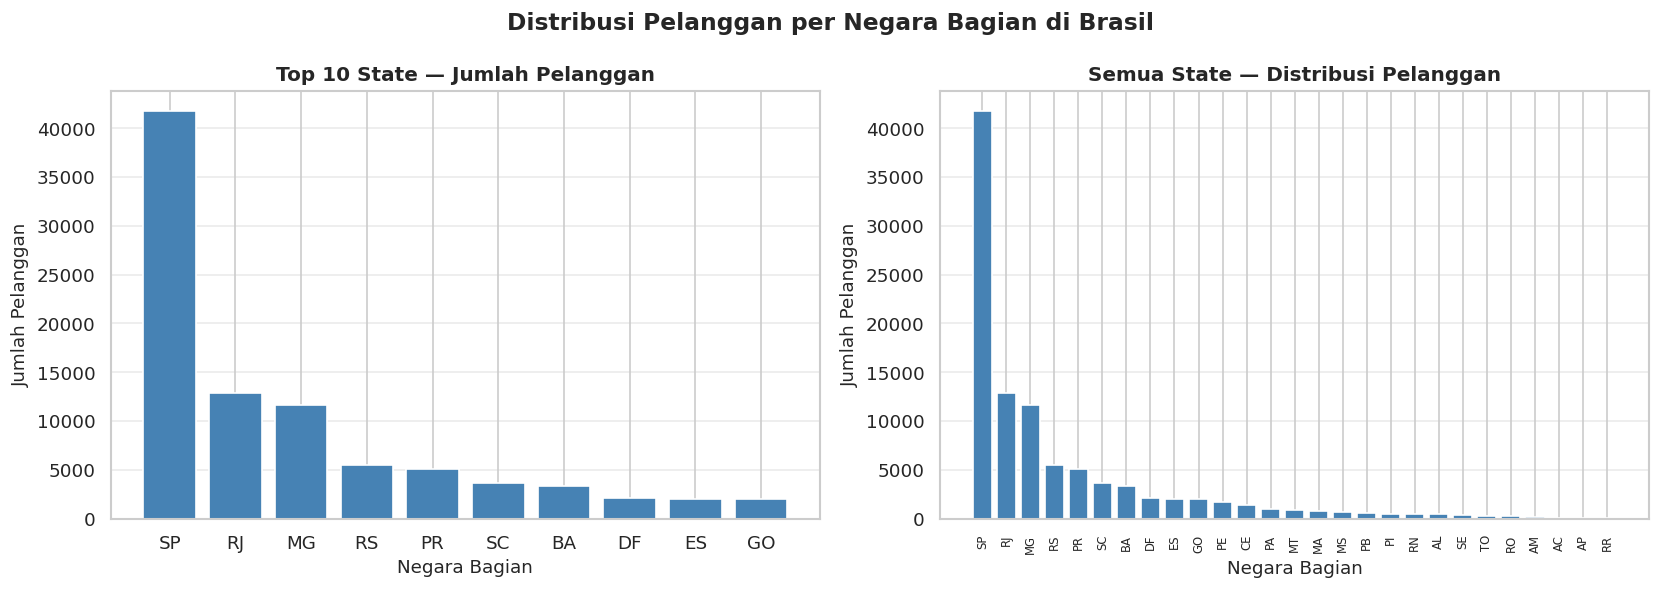

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Pelanggan per Negara Bagian di Brasil',
             fontsize=14, fontweight='bold')

#Bar chart top 10 state
ax1 = axes[0]
top10 = state_dist.head(10)

ax1.bar(top10['state'], top10['jumlah'], color='steelblue', edgecolor='white')
ax1.set_xlabel('Negara Bagian', fontsize=11)
ax1.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax1.set_title('Top 10 State — Jumlah Pelanggan', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.4)

#semua state
ax2 = axes[1]

ax2.bar(state_dist['state'], state_dist['jumlah'], color='steelblue', edgecolor='white')
ax2.set_xlabel('Negara Bagian', fontsize=11)
ax2.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax2.set_title('Semua State — Distribusi Pelanggan', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=90, labelsize=7)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('viz_pertanyaan1.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Pertanyaan 1:**
- **São Paulo (SP)** adalah negara bagian dengan pelanggan terbanyak: **41.746 pelanggan** —
- Lima negara bagian teratas (SP, RJ, MG, RS, PR) bersama-sama mencakup **~73%** dari seluruh pelanggan.
- 22 negara bagian sisanya hanya menyumbang **~27%**, menunjukkan konsentrasi pelanggan yang sangat tinggi di negara bagian ekonomi utama Brasil.

### Pertanyaan 2: Bagaimana distribusi pelanggan berdasarkan wilayah Brasil?

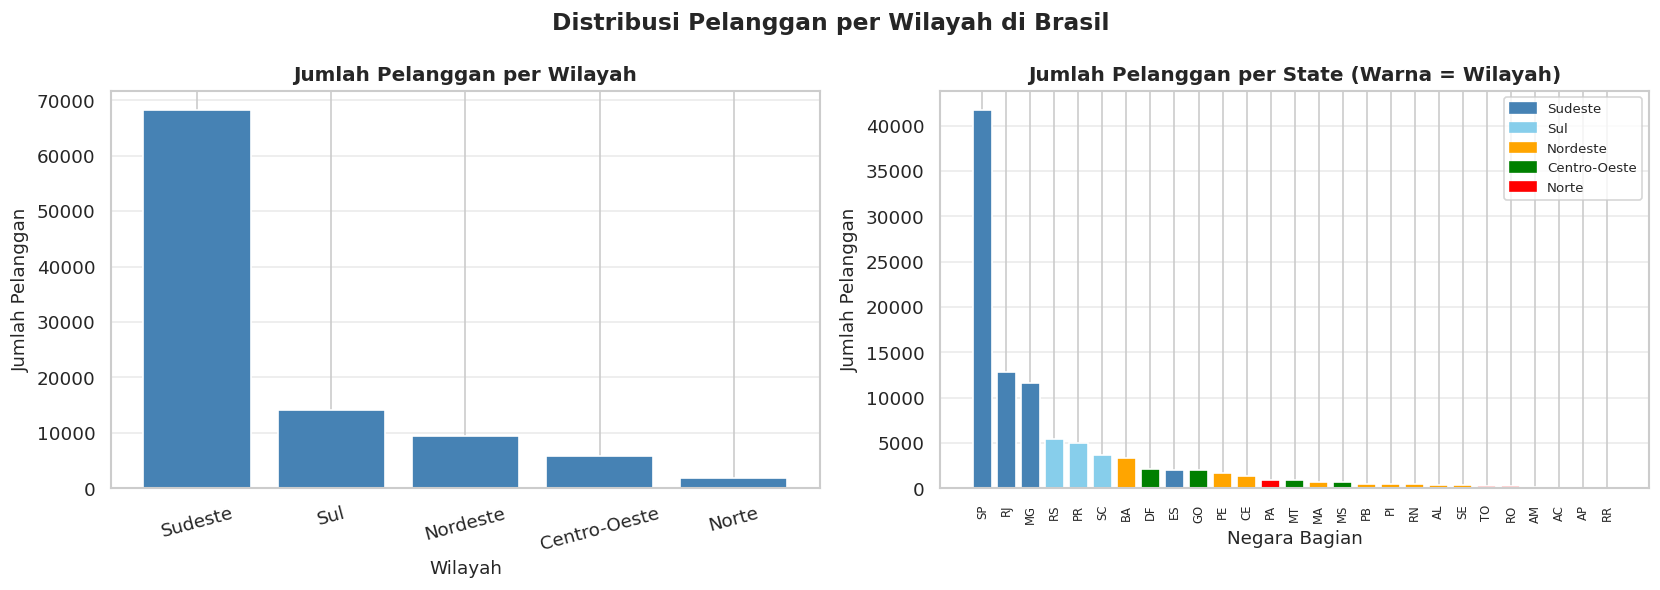

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Pelanggan per Wilayah di Brasil',
             fontsize=14, fontweight='bold')

#Bar chart per region
ax1 = axes[0]

ax1.bar(region_dist['wilayah'], region_dist['jumlah'], color='steelblue', edgecolor='white')
ax1.set_xlabel('Wilayah', fontsize=11)
ax1.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax1.set_title('Jumlah Pelanggan per Wilayah', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(axis='y', alpha=0.4)

# Bar chart per state
ax2 = axes[1]

# Gabungkan info region ke state_dist
state_dist['region'] = state_dist['state'].map(region_map)
colors = state_dist['region'].map({
    'Sudeste'     : 'steelblue',
    'Sul'         : 'skyblue',
    'Nordeste'    : 'orange',
    'Centro-Oeste': 'green',
    'Norte'       : 'red'
})

ax2.bar(state_dist['state'], state_dist['jumlah'], color=colors, edgecolor='white')
ax2.set_xlabel('Negara Bagian', fontsize=11)
ax2.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax2.set_title('Jumlah Pelanggan per State (Warna = Wilayah)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=90, labelsize=7)
ax2.grid(axis='y', alpha=0.4)

# Legend wilayah
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='steelblue', label='Sudeste'),
    Patch(color='skyblue',   label='Sul'),
    Patch(color='orange',    label='Nordeste'),
    Patch(color='green',     label='Centro-Oeste'),
    Patch(color='red',       label='Norte'),
]
ax2.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig('viz_pertanyaan2.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Pertanyaan 2:**
- Wilayah **Sudeste** mendominasi dengan **68.265 pelanggan (68.65%)**, didorong oleh SP, RJ, dan MG.
- Wilayah **Sul** berada di posisi kedua dengan **14.148 pelanggan (14.22%)**.
- Wilayah **Norte** hanya memiliki **1.851 pelanggan (1.86%)** — penetrasi e-commerce sangat rendah.
- Ketidakseimbangan ini menunjukkan **peluang ekspansi pasar** yang besar di wilayah Norte dan Nordeste.

## Analisis Lanjutan (Opsional)

In [23]:
# Analisis Lanjutan: Clustering Kota Berdasarkan Jumlah Pelanggan

# Hitung jumlah pelanggan unik per kota
city_df = df.groupby('customer_city')['customer_unique_id'].nunique().reset_index()
city_df.columns = ['kota', 'jumlah_pelanggan']
city_df = city_df.sort_values('jumlah_pelanggan', ascending=False)

# Bagi kota ke dalam 3 kelompok pakai pd.cut (binning)
city_df['kategori'] = pd.cut(
    city_df['jumlah_pelanggan'],
    bins=[0, 50, 500, city_df['jumlah_pelanggan'].max()],
    labels=['Kecil', 'Menengah', 'Besar']
)

# Lihat hasilnya
print('Jumlah kota per kategori:')
print(city_df['kategori'].value_counts())
print()
print('Contoh kota tiap kategori:')
print(city_df.groupby('kategori').head(3))

Jumlah kota per kategori:
kategori
Kecil       3858
Menengah     240
Besar         21
Name: count, dtype: int64

Contoh kota tiap kategori:
                kota  jumlah_pelanggan  kategori
3597       sao paulo             14984     Besar
3155  rio de janeiro              6620     Besar
453   belo horizonte              2672     Besar
3132  ribeirao preto               489  Menengah
448            belem               435  Menengah
2506     nova iguacu               432  Menengah
1638            ijui                50     Kecil
440        bebedouro                50     Kecil
222        apucarana                50     Kecil


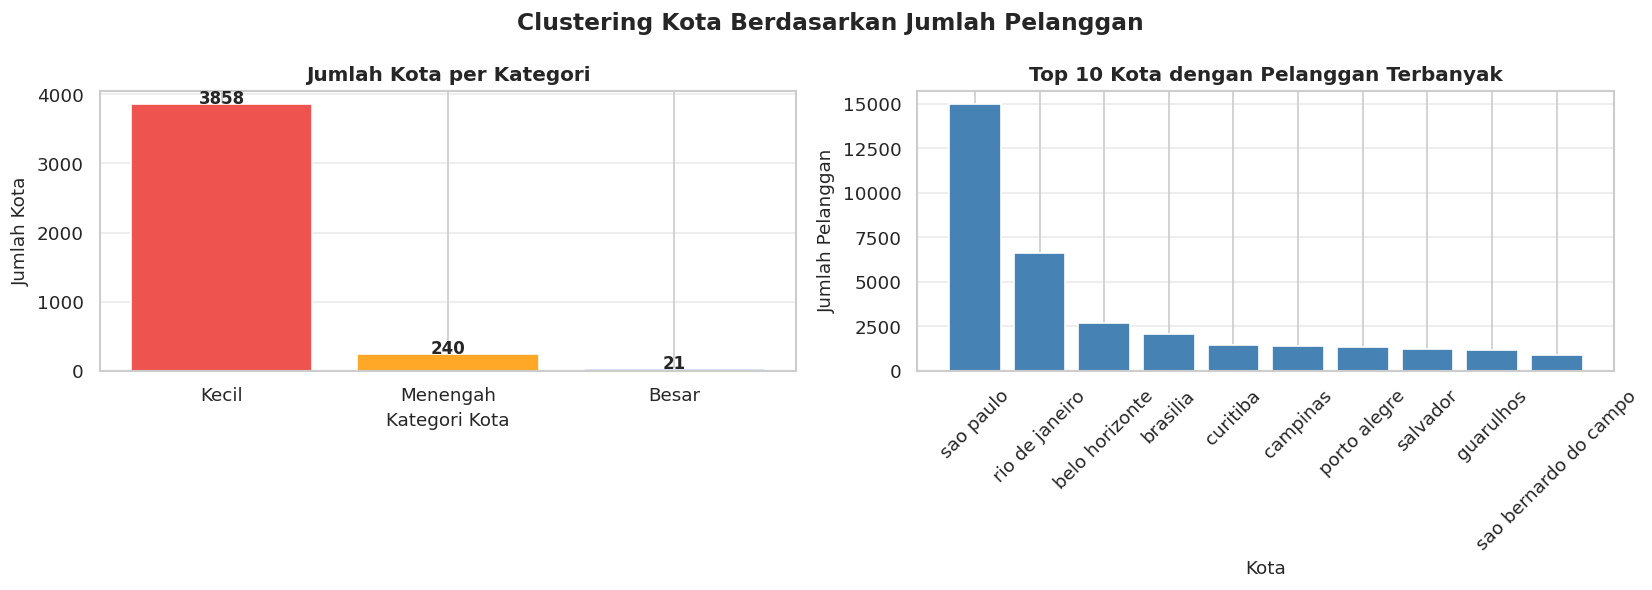

In [24]:
# Visualisasi clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clustering Kota Berdasarkan Jumlah Pelanggan', fontsize=14, fontweight='bold')

#jumlah kota per kategori
ax1 = axes[0]

kategori_count = city_df['kategori'].value_counts().reindex(['Kecil', 'Menengah', 'Besar'])

ax1.bar(kategori_count.index, kategori_count.values, color=['#EF5350', '#FFA726', '#1565C0'], edgecolor='white')
ax1.set_xlabel('Kategori Kota', fontsize=11)
ax1.set_ylabel('Jumlah Kota', fontsize=11)
ax1.set_title('Jumlah Kota per Kategori', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.4)

for i, val in enumerate(kategori_count.values):
    ax1.text(i, val + 10, str(val), ha='center', fontsize=10, fontweight='bold')

# top 10 kota terbanyak
ax2 = axes[1]

top10_city = city_df.head(10)

ax2.bar(top10_city['kota'], top10_city['jumlah_pelanggan'], color='steelblue', edgecolor='white')
ax2.set_xlabel('Kota', fontsize=11)
ax2.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax2.set_title('Top 10 Kota dengan Pelanggan Terbanyak', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('viz_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Analisis Lanjutan (Clustering):**
- Dari total **4.119 kota**, sebanyak **3.858 kota (93.7%)** masuk kategori *Kecil* (0–50 pelanggan) — menunjukkan sebagian besar kota memiliki penetrasi e-commerce yang sangat rendah.
- Hanya **240 kota (5.8%)** termasuk kategori *Menengah* (50–500 pelanggan), dan **21 kota (0.5%)** masuk kategori *Besar* (>500 pelanggan).
- **São Paulo** memimpin jauh dengan hampir 15.000 pelanggan unik.
- **Implikasi bisnis:** Fokus utama sebaiknya diarahkan ke 21 kota kategori *Besar* karena menyumbang volume transaksi terbesar, sementara kota *Kecil* membutuhkan pendekatan yang lebih targeted untuk meningkatkan penetrasi.

## Conclusion

**Konklusi Pertanyaan 1 — Distribusi per Negara Bagian:**
São Paulo (SP) adalah negara bagian dengan pelanggan e-commerce terbanyak di Brasil, yaitu **41.746 pelanggan (41.98%)** dari total 99.441 transaksi. Lima negara bagian teratas (SP, RJ, MG, RS, PR) secara bersama-sama menyumbang **~73%** dari total pelanggan. Hal ini mencerminkan konsentrasi aktivitas ekonomi digital di wilayah yang padat penduduk dan memiliki infrastruktur yang lebih maju.

**Konklusi Pertanyaan 2 — Distribusi per Wilayah:**
Terdapat ketidakseimbangan distribusi pelanggan yang sangat signifikan antar wilayah Brasil. Wilayah **Sudeste mendominasi dengan 68.65%** dari total pelanggan, sementara wilayah **Norte hanya 1.86%**. Ketidakseimbangan ini mengindikasikan bahwa penetrasi e-commerce masih sangat rendah di wilayah Norte dan Nordeste, yang sekaligus menjadi **peluang bisnis besar** untuk ekspansi platform e-commerce ke pasar yang belum tergarap secara optimal.

**Rekomendasi Bisnis:**
1. **Pertahankan posisi** di SP dan kota-kota besar Sudeste dengan optimasi logistik dan layanan.
2. **Ekspansi ke Norte & Nordeste** — wilayah ini under-represented dan memiliki potensi pertumbuhan.
3. **Strategi berbeda per segmen kota** berdasarkan hasil clustering: pendekatan *mass-market* untuk kota Besar, dan *targeted/regional* untuk kota Mikro.

In [25]:
# Simpan hasil cleaning ke CSV untuk dashboard
df.to_csv('main_data.csv', index=False)

In [29]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>